In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [2]:
df=pd.read_csv('players_20.csv')

In [3]:
df.head()

,sofifa_id,player_url,short_name,long_name,age,dob,height_cm,weight_kg,nationality,club,...,lwb,ldm,cdm,rdm,rwb,lb,lcb,cb,rcb,rb
0,158023,https://sofifa.com/player/158023/lionel-messi/...,L. Messi,Lionel Andrés Messi Cuccittini,32,1987-06-24,170,72,Argentina,FC Barcelona,...,68+2,66+2,66+2,66+2,68+2,63+2,52+2,52+2,52+2,63+2
1,20801,https://sofifa.com/player/20801/c-ronaldo-dos-...,Cristiano Ronaldo,Cristiano Ronaldo dos Santos Aveiro,34,1985-02-05,187,83,Portugal,Juventus,...,65+3,61+3,61+3,61+3,65+3,61+3,53+3,53+3,53+3,61+3
2,190871,https://sofifa.com/player/190871/neymar-da-sil...,Neymar Jr,Neymar da Silva Santos Junior,27,1992-02-05,175,68,Brazil,Paris Saint-Germain,...,66+3,61+3,61+3,61+3,66+3,61+3,46+3,46+3,46+3,61+3
3,200389,https://sofifa.com/player/200389/jan-oblak/20/...,J. Oblak,Jan Oblak,26,1993-01-07,188,87,Slovenia,Atlético Madrid,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,183277,https://sofifa.com/player/183277/eden-hazard/2...,E. Hazard,Eden Hazard,28,1991-01-07,175,74,Belgium,Real Madrid,...,66+3,63+3,63+3,63+3,66+3,61+3,49+3,49+3,49+3,61+3


In [4]:
df.shape

(18278, 104)

In [5]:
pd.set_option('display.max_rows',200)
df.head(5).T

,0,1,2,3,4
sofifa_id,158023,20801,190871,200389,183277
player_url,https://sofifa.com/player/158023/lionel-messi/...,https://sofifa.com/player/20801/c-ronaldo-dos-...,https://sofifa.com/player/190871/neymar-da-sil...,https://sofifa.com/player/200389/jan-oblak/20/...,https://sofifa.com/player/183277/eden-hazard/2...
short_name,L. Messi,Cristiano Ronaldo,Neymar Jr,J. Oblak,E. Hazard
long_name,Lionel Andrés Messi Cuccittini,Cristiano Ronaldo dos Santos Aveiro,Neymar da Silva Santos Junior,Jan Oblak,Eden Hazard
age,32,34,27,26,28
dob,1987-06-24,1985-02-05,1992-02-05,1993-01-07,1991-01-07
height_cm,170,187,175,188,175
weight_kg,72,83,68,87,74
nationality,Argentina,Portugal,Brazil,Slovenia,Belgium
club,FC Barcelona,Juventus,Paris Saint-Germain,Atlético Madrid,Real Madrid


In [6]:
df.columns.tolist()

['sofifa_id',
 'player_url',
 'short_name',
 'long_name',
 'age',
 'dob',
 'height_cm',
 'weight_kg',
 'nationality',
 'club',
 'overall',
 'potential',
 'value_eur',
 'wage_eur',
 'player_positions',
 'preferred_foot',
 'international_reputation',
 'weak_foot',
 'skill_moves',
 'work_rate',
 'body_type',
 'real_face',
 'release_clause_eur',
 'player_tags',
 'team_position',
 'team_jersey_number',
 'loaned_from',
 'joined',
 'contract_valid_until',
 'nation_position',
 'nation_jersey_number',
 'pace',
 'shooting',
 'passing',
 'dribbling',
 'defending',
 'physic',
 'gk_diving',
 'gk_handling',
 'gk_kicking',
 'gk_reflexes',
 'gk_speed',
 'gk_positioning',
 'player_traits',
 'attacking_crossing',
 'attacking_finishing',
 'attacking_heading_accuracy',
 'attacking_short_passing',
 'attacking_volleys',
 'skill_dribbling',
 'skill_curve',
 'skill_fk_accuracy',
 'skill_long_passing',
 'skill_ball_control',
 'movement_acceleration',
 'movement_sprint_speed',
 'movement_agility',
 'movement_re

In [7]:
df.dtypes.value_counts()

int64      45
object     43
float64    16
Name: count, dtype: int64

In [8]:
df.drop(columns=['sofifa_id', 'player_url', 'long_name', 'dob', 'real_face', 'player_tags', 'body_type', 'player_tags', 'player_traits', 'nation_position', 'nation_jersey_number', 'loaned_from', 'team_jersey_number', 'team_position', 'joined', 'contract_valid_until',
    'release_clause_eur','gk_diving', 'gk_handling', 'gk_kicking','gk_reflexes', 'gk_positioning'], inplace=True, errors='ignore') 

In [9]:
print('Remaining columns:', df.shape[1])


Remaining columns: 83


In [10]:
pd.set_option('display.max_rows',200)
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,18278.0,2.528329e+01,4.656964e+00,16.0,22.0,25.0,29.0,42.0
height_cm,18278.0,1.813622e+02,6.756961e+00,156.0,177.0,181.0,186.0,205.0
weight_kg,18278.0,7.527634e+01,7.047744e+00,50.0,70.0,75.0,80.0,110.0
overall,18278.0,6.624499e+01,6.949953e+00,48.0,62.0,66.0,71.0,94.0
potential,18278.0,7.154689e+01,6.139669e+00,49.0,67.0,71.0,75.0,95.0
value_eur,18278.0,2.484038e+06,5.585481e+06,0.0,325000.0,700000.0,2100000.0,105500000.0
wage_eur,18278.0,9.456943e+03,2.135171e+04,0.0,1000.0,3000.0,8000.0,565000.0
international_reputation,18278.0,1.103184e+00,3.788605e-01,1.0,1.0,1.0,1.0,5.0
weak_foot,18278.0,2.944250e+00,6.646562e-01,1.0,3.0,3.0,3.0,5.0
skill_moves,18278.0,2.368038e+00,7.650376e-01,1.0,2.0,2.0,3.0,5.0


In [11]:
df[['attack_work_rate', 'defense_work_rate']] = df['work_rate'].str.split('/', expand=True)
df.drop(columns=['work_rate'], inplace=True)
print(df['attack_work_rate'].value_counts())
print(df['defense_work_rate'].value_counts())

attack_work_rate
Medium    12479
High       4886
Low         913
Name: count, dtype: int64
defense_work_rate
Medium    13552
High       3121
Low        1605
Name: count, dtype: int64


In [12]:
df.shape

(18278, 84)

In [13]:
df['primary_position'] = df['player_positions'].str.split(',').str[0].str.strip()
print(df['primary_position'].value_counts())

primary_position
CB     3162
ST     2582
CM     2193
GK     2036
CDM    1424
RB     1314
LB     1303
CAM    1146
RM     1050
LM     1049
LW      378
RW      369
CF      113
LWB      90
RWB      69
Name: count, dtype: int64


In [14]:
position_cols = ['ls', 'st', 'rs', 'lw', 'lf', 'cf', 'rf', 'rw',
            'lam', 'cam', 'ram', 'lm', 'lcm', 'cm', 'rcm',
            'rm', 'lwb', 'ldm', 'cdm', 'rdm', 'rwb',
            'lb', 'lcb', 'cb', 'rcb', 'rb']

for col in position_cols:
    if col in df.columns:
        df[col] = df[col].astype(str).str.split('+').str[0].astype(float)

In [15]:
df

,short_name,age,height_cm,weight_kg,nationality,club,overall,potential,value_eur,wage_eur,...,rdm,rwb,lb,lcb,cb,rcb,rb,attack_work_rate,defense_work_rate,primary_position
0,L. Messi,32,170,72,Argentina,FC Barcelona,94,94,95500000,565000,...,66.0,68.0,63.0,52.0,52.0,52.0,63.0,Medium,Low,RW
1,Cristiano Ronaldo,34,187,83,Portugal,Juventus,93,93,58500000,405000,...,61.0,65.0,61.0,53.0,53.0,53.0,61.0,High,Low,ST
2,Neymar Jr,27,175,68,Brazil,Paris Saint-Germain,92,92,105500000,290000,...,61.0,66.0,61.0,46.0,46.0,46.0,61.0,High,Medium,LW
3,J. Oblak,26,188,87,Slovenia,Atlético Madrid,91,93,77500000,125000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Medium,Medium,GK
4,E. Hazard,28,175,74,Belgium,Real Madrid,91,91,90000000,470000,...,63.0,66.0,61.0,49.0,49.0,49.0,61.0,High,Medium,LW
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18273,Shao Shuai,22,186,79,China PR,Beijing Renhe FC,48,56,40000,2000,...,42.0,43.0,45.0,46.0,46.0,46.0,45.0,Medium,High,CB
18274,Xiao Mingjie,22,177,66,China PR,Shanghai SIPG FC,48,56,40000,2000,...,43.0,44.0,46.0,47.0,47.0,47.0,46.0,Medium,Medium,CB
18275,Zhang Wei,19,186,75,China PR,Hebei China Fortune FC,48,56,40000,1000,...,49.0,47.0,47.0,49.0,49.0,49.0,47.0,Low,Medium,CM
18276,Wang Haijian,18,185,74,China PR,Shanghai Greenland Shenhua FC,48,54,40000,1000,...,48.0,48.0,48.0,49.0,49.0,49.0,48.0,Low,Low,CM


In [16]:
df.replace('nan', np.nan, inplace=True)

In [17]:
df.isnull().sum()

short_name                        0
age                               0
height_cm                         0
weight_kg                         0
nationality                       0
club                              0
overall                           0
potential                         0
value_eur                         0
wage_eur                          0
player_positions                  0
preferred_foot                    0
international_reputation          0
weak_foot                         0
skill_moves                       0
pace                           2036
shooting                       2036
passing                        2036
dribbling                      2036
defending                      2036
physic                         2036
gk_speed                      16242
attacking_crossing                0
attacking_finishing               0
attacking_heading_accuracy        0
attacking_short_passing           0
attacking_volleys                 0
skill_dribbling             

In [18]:
df.isnull().sum()[df.isnull().sum() > 0]

pace          2036
shooting      2036
passing       2036
dribbling     2036
defending     2036
physic        2036
gk_speed     16242
ls            2036
st            2036
rs            2036
lw            2036
lf            2036
cf            2036
rf            2036
rw            2036
lam           2036
cam           2036
ram           2036
lm            2036
lcm           2036
cm            2036
rcm           2036
rm            2036
lwb           2036
ldm           2036
cdm           2036
rdm           2036
rwb           2036
lb            2036
lcb           2036
cb            2036
rcb           2036
rb            2036
dtype: int64

In [19]:
df[df['pace'].isnull()]['primary_position'].value_counts()

primary_position
GK    2036
Name: count, dtype: int64

In [20]:
df[df['gk_speed'].isnull()]['primary_position'].value_counts().head(10)

primary_position
CB     3162
ST     2582
CM     2193
CDM    1424
RB     1314
LB     1303
CAM    1146
RM     1050
LM     1049
LW      378
Name: count, dtype: int64

In [22]:
df.drop(columns=['player_positions'], inplace=True)

In [23]:
df.shape

(18278, 84)

In [24]:
df.head(3).T

,0,1,2
short_name,L. Messi,Cristiano Ronaldo,Neymar Jr
age,32,34,27
height_cm,170,187,175
weight_kg,72,83,68
nationality,Argentina,Portugal,Brazil
club,FC Barcelona,Juventus,Paris Saint-Germain
overall,94,93,92
potential,94,93,92
value_eur,95500000,58500000,105500000
wage_eur,565000,405000,290000


In [25]:
df.to_pickle('fifa20_cleaned.pkl')

## Exploratory Data Analysis (EDA)

data is cleaned and loaded from pickle. let's explore it.

EDA is structured in 3 parts:
- Univariate 
- Bivariate  
- Multivariate

### Univariate Analysis — Numerical Features

In [27]:
df['age'].describe()

count    18278.000000
mean        25.283291
std          4.656964
min         16.000000
25%         22.000000
50%         25.000000
75%         29.000000
max         42.000000
Name: age, dtype: float64

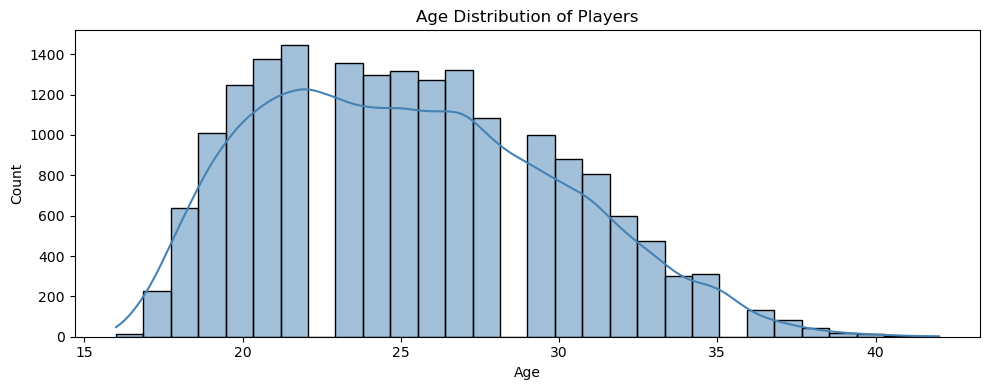

In [28]:
plt.figure(figsize=(10, 4))
sns.histplot(df['age'], bins=30, kde=True, color='steelblue')
plt.title('Age Distribution of Players')
plt.xlabel('Age')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

most player are between 20-25 years old.
distribution is right skewed - fewer older players in the game


In [37]:
df['overall'].describe()

count    18278.000000
mean        66.244994
std          6.949953
min         48.000000
25%         62.000000
50%         66.000000
75%         71.000000
max         94.000000
Name: overall, dtype: float64

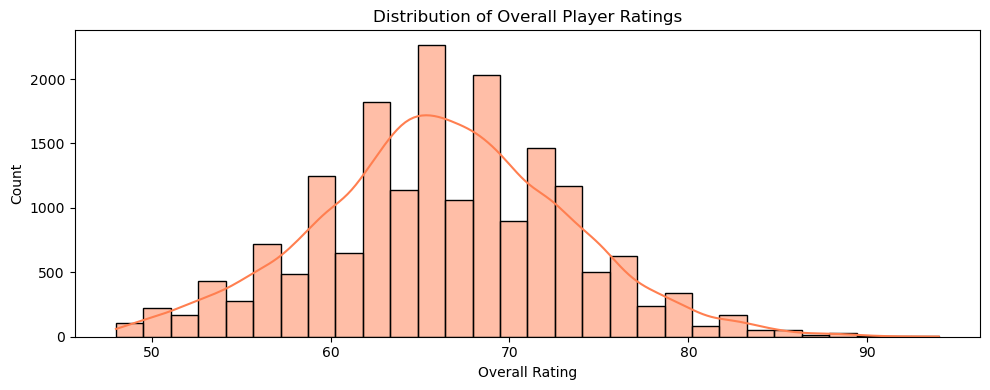

In [38]:
plt.figure(figsize=(10, 4))
sns.histplot(df['overall'], bins=30, kde=True, color='coral')
plt.title('Distribution of Overall Player Ratings')
plt.xlabel('Overall Rating')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

overall rating follows a roughly normal distribution centered around 66. 
very few players are elite (85+) — the game reflects real football well.

In [35]:
df['wage_eur'].describe()

count     18278.000000
mean       9456.942773
std       21351.714095
min           0.000000
25%        1000.000000
50%        3000.000000
75%        8000.000000
max      565000.000000
Name: wage_eur, dtype: float64

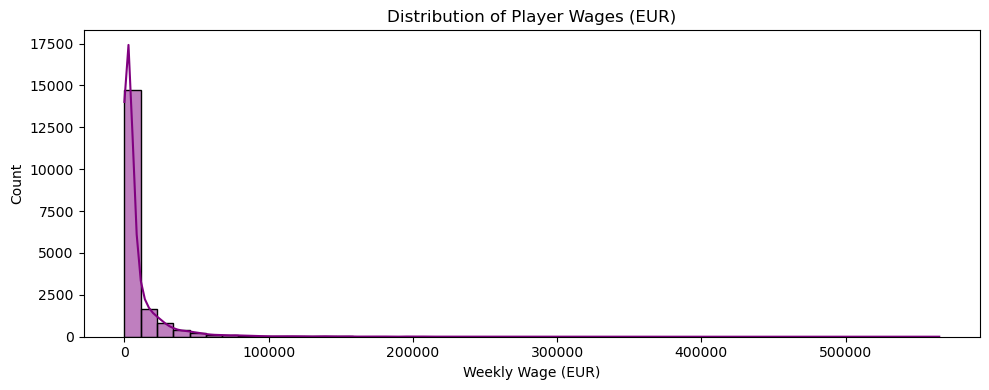

In [36]:
plt.figure(figsize=(10, 4))
sns.histplot(df['wage_eur'], bins=50, kde=True, color='purple')
plt.title('Distribution of Player Wages (EUR)')
plt.xlabel('Weekly Wage (EUR)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

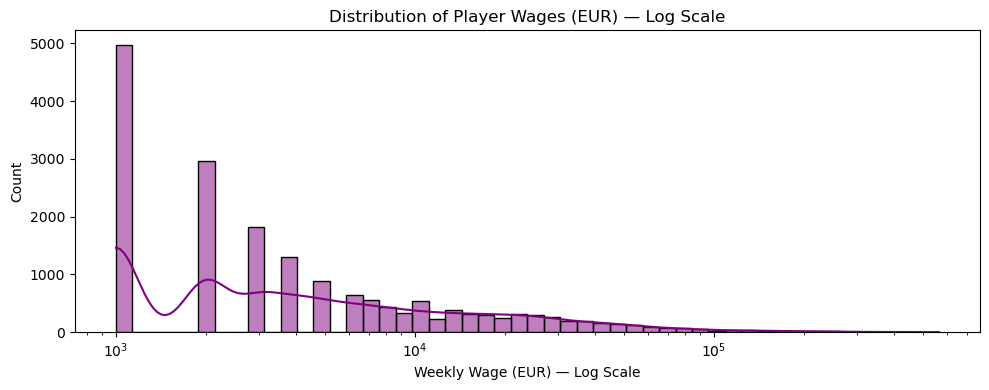

In [40]:
plt.figure(figsize=(10, 4))
sns.histplot(df[df['wage_eur'] > 0]['wage_eur'], bins=50, kde=True, color='purple', log_scale=True)
plt.title('Distribution of Player Wages (EUR) — Log Scale')
plt.xlabel('Weekly Wage (EUR) — Log Scale')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

wage distribution is heavily right skewed — most players earn under €10,000/week.
log scale reveals two groups: lower league players (~€1000) and mid tier (~€3000-5000).
a tiny elite earn €100,000+.

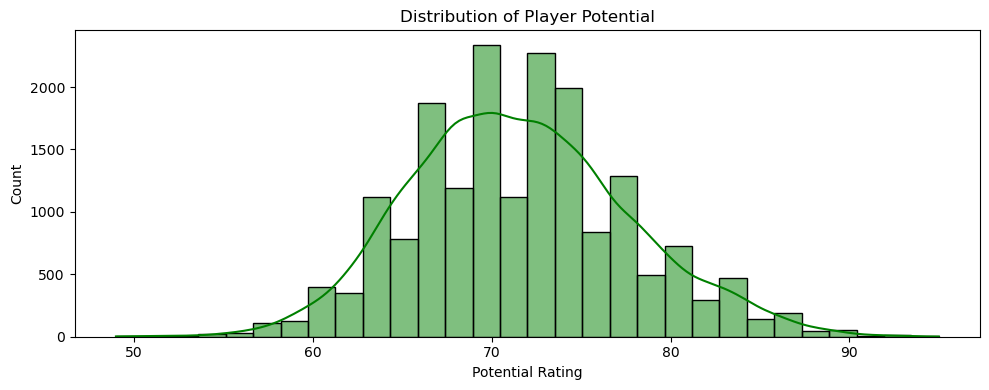

In [41]:
plt.figure(figsize=(10, 4))
sns.histplot(df['potential'], bins=30, kde=True, color='green')
plt.title('Distribution of Player Potential')
plt.xlabel('Potential Rating')
plt.ylabel('Count')
plt.tight_layout()
plt.show()